Skins and online Editor https://www.minecraftskins.net

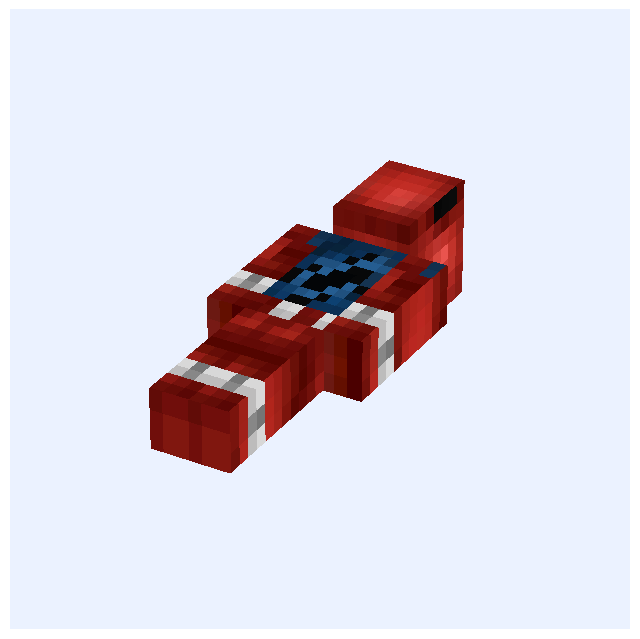

In [5]:
"""
Minecraft Skin Viewer mit echten Pixeltexturen
================================================

Features:
- echte Minecraft-Skin-Texturen
- 64x64 Skin Support
- rotierbare 3D-Figur
- Pixel-Look
- Animation
- matplotlib only

Installation:
    pip install pillow matplotlib numpy

Start:
    python skin_viewer_textured.py skin.png
"""

import sys
import numpy as np
from PIL import Image

import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation


# ============================================================
# Skin laden
# ============================================================

if len(sys.argv) < 2:
    print("Usage: python skin_viewer_textured.py skin.png")
    sys.exit(1)

skin_path = sys.argv[1]

#s kin = Image.open("../data/skins/bad/spiderman/spiderman_96606.png").convert("RGBA")


skin = Image.open("spiderman_96606.png").convert("RGBA")
skin = np.array(skin) / 255.0


# ============================================================
# UV Helper
# ============================================================

def tex(x, y, w, h):
    """
    Minecraft UV Bereich ausschneiden.
    Flip wegen matplotlib Orientierung.
    """
    t = skin[y:y+h, x:x+w]
    return np.flipud(t)


# ============================================================
# Minecraft UV Mapping
# ============================================================

HEAD = {
    "front": tex(8, 8, 8, 8),
    "back": tex(24, 8, 8, 8),
    "left": tex(16, 8, 8, 8),
    "right": tex(0, 8, 8, 8),
    "top": tex(8, 0, 8, 8),
    "bottom": tex(16, 0, 8, 8),
}

BODY = {
    "front": tex(20, 20, 8, 12),
    "back": tex(32, 20, 8, 12),
    "left": tex(28, 20, 4, 12),
    "right": tex(16, 20, 4, 12),
    "top": tex(20, 16, 8, 4),
    "bottom": tex(28, 16, 8, 4),
}

ARM = {
    "front": tex(44, 20, 4, 12),
    "back": tex(52, 20, 4, 12),
    "left": tex(48, 20, 4, 12),
    "right": tex(40, 20, 4, 12),
    "top": tex(44, 16, 4, 4),
    "bottom": tex(48, 16, 4, 4),
}

LEG = {
    "front": tex(4, 20, 4, 12),
    "back": tex(12, 20, 4, 12),
    "left": tex(8, 20, 4, 12),
    "right": tex(0, 20, 4, 12),
    "top": tex(4, 16, 4, 4),
    "bottom": tex(8, 16, 4, 4),
}


# ============================================================
# Texturierte Fläche
# ============================================================

def draw_face(ax, X, Y, Z, texture):
    """
    Zeichnet eine texturierte Fläche.
    """

    ax.plot_surface(
        X,
        Y,
        Z,
        rstride=1,
        cstride=1,
        facecolors=texture,
        shade=False,
        antialiased=False
    )


# ============================================================
# Würfel mit echten Texturen
# ============================================================

def draw_cube(ax, origin, size, texmap):

    ox, oy, oz = origin
    sx, sy, sz = size

    # --------------------------------------------------------
    # FRONT
    # --------------------------------------------------------
    t = texmap["front"]

    x = np.linspace(ox, ox+sx, t.shape[1])
    y = np.linspace(oy, oy+sy, t.shape[0])

    X, Y = np.meshgrid(x, y)
    Z = np.full_like(X, oz)

    draw_face(ax, X, Y, Z, t)

    # --------------------------------------------------------
    # BACK
    # --------------------------------------------------------
    t = texmap["back"]

    x = np.linspace(ox+sx, ox, t.shape[1])
    y = np.linspace(oy, oy+sy, t.shape[0])

    X, Y = np.meshgrid(x, y)
    Z = np.full_like(X, oz+sz)

    draw_face(ax, X, Y, Z, t)

    # --------------------------------------------------------
    # LEFT
    # --------------------------------------------------------
    t = texmap["left"]

    z = np.linspace(oz+sz, oz, t.shape[1])
    y = np.linspace(oy, oy+sy, t.shape[0])

    Z, Y = np.meshgrid(z, y)
    X = np.full_like(Z, ox)

    draw_face(ax, X, Y, Z, t)

    # --------------------------------------------------------
    # RIGHT
    # --------------------------------------------------------
    t = texmap["right"]

    z = np.linspace(oz, oz+sz, t.shape[1])
    y = np.linspace(oy, oy+sy, t.shape[0])

    Z, Y = np.meshgrid(z, y)
    X = np.full_like(Z, ox+sx)

    draw_face(ax, X, Y, Z, t)

    # --------------------------------------------------------
    # TOP
    # --------------------------------------------------------
    t = texmap["top"]

    x = np.linspace(ox, ox+sx, t.shape[1])
    z = np.linspace(oz, oz+sz, t.shape[0])

    X, Z = np.meshgrid(x, z)
    Y = np.full_like(X, oy+sy)

    draw_face(ax, X, Y, Z, t)

    # --------------------------------------------------------
    # BOTTOM
    # --------------------------------------------------------
    t = texmap["bottom"]

    x = np.linspace(ox, ox+sx, t.shape[1])
    z = np.linspace(oz+sz, oz, t.shape[0])

    X, Z = np.meshgrid(x, z)
    Y = np.full_like(X, oy)

    draw_face(ax, X, Y, Z, t)


# ============================================================
# Plot Setup
# ============================================================

fig = plt.figure(figsize=(8, 10))
ax = fig.add_subplot(111, projection='3d')

ax.set_facecolor((0.92, 0.95, 1.0))

# ============================================================
# Figur
# ============================================================

# Kopf
draw_cube(ax, (2, 12, 2), (4,4,4), HEAD)

# Körper
draw_cube(ax, (2, 6, 3), (4,6,2), BODY)

# Arme
draw_cube(ax, (0, 6, 3), (2,6,2), ARM)
draw_cube(ax, (6, 6, 3), (2,6,2), ARM)

# Beine
draw_cube(ax, (2, 0, 3), (2,6,2), LEG)
draw_cube(ax, (4, 0, 3), (2,6,2), LEG)

# ============================================================
# Kamera
# ============================================================

ax.set_xlim(-2, 10)
ax.set_ylim(0, 18)
ax.set_zlim(0, 8)

ax.set_box_aspect([1, 2, 1])

ax.axis("off")


# ============================================================
# Rotation Animation
# ============================================================

def update(frame):
    ax.view_init(
        elev=20,
        azim=frame
    )
    return fig,


ani = FuncAnimation(
    fig,
    update,
    frames=np.arange(0, 360, 2),
    interval=40,
    blit=False
)

plt.show()